# Technical Presentation  
## Student Dropout Early-Warning Model

**Final model:** XGBoost  
**Prediction horizon:** End of Semester 1  
**Frozen threshold:** 0.48

**Peer-review focus:** model validation, explainability, fairness, and governance.

# Model Scope and Data Contract

| Item | Design choice |
|---|---|
| Prediction Task | Binary classification: **Graduate vs Dropout** |
| Prediction Horizon | **End of Semester 1 only** |
| Raw Inputs | **37 final Model B inputs** |
| Transformed Features | **228 post-preprocessing features** |
| Training records | **2,904** |
| Untouched holdout records | **726** |
| Train/test index overlap | **0** |

**Why the horizon matters:** Semester 1 completion is the dominant signal. Using it before the end of Semester 1 would create temporal leakage. The final holdout stayed separate from tuning and threshold selection.

# Modeling Pipeline

```text
Raw UCI data
   ↓
Exclude unresolved Enrolled outcomes
   ↓
Feature engineering: preparedness, financial risk, Semester 1 rates
   ↓
Preprocess: impute, scale numeric features, one-hot encode categoricals
   ↓
Train candidate models: Logistic Regression, Random Forest, XGBoost
   ↓
Tune via stratified CV / OOF predictions
   ↓
Freeze XGBoost + threshold 0.48
   ↓
Evaluate once on untouched holdout
```

**Transformed feature space:** 37 raw inputs → 228 model features.

# Model Selection and Operating Point

| Model               |   Threshold |   Precision |   Recall |     F1 |   Balanced accuracy |   Alert rate |
|:--------------------|------------:|------------:|---------:|-------:|--------------------:|-------------:|
| Logistic Regression |      0.4600 |      0.8037 |   0.9085 | 0.8529 |              0.8830 |       0.4421 |
| XGBoost             |      0.4800 |      0.8581 |   0.8732 | 0.8656 |              0.8902 |       0.3981 |

**Final choice:** XGBoost reduced false positives and operational workload while improving F1 and balanced accuracy compared with the Logistic Regression finalist.

# Final Holdout Performance

| Metric            |   Value |
|:------------------|--------:|
| Accuracy          |  0.8939 |
| Balanced accuracy |  0.8902 |
| Precision         |  0.8581 |
| Recall            |  0.8732 |
| F1                |  0.8656 |
| F2                |  0.8702 |
| Specificity       |  0.9072 |
| ROC-AUC           |  0.9540 |
| PR-AUC            |  0.9492 |
| Alert rate        |  0.3981 |

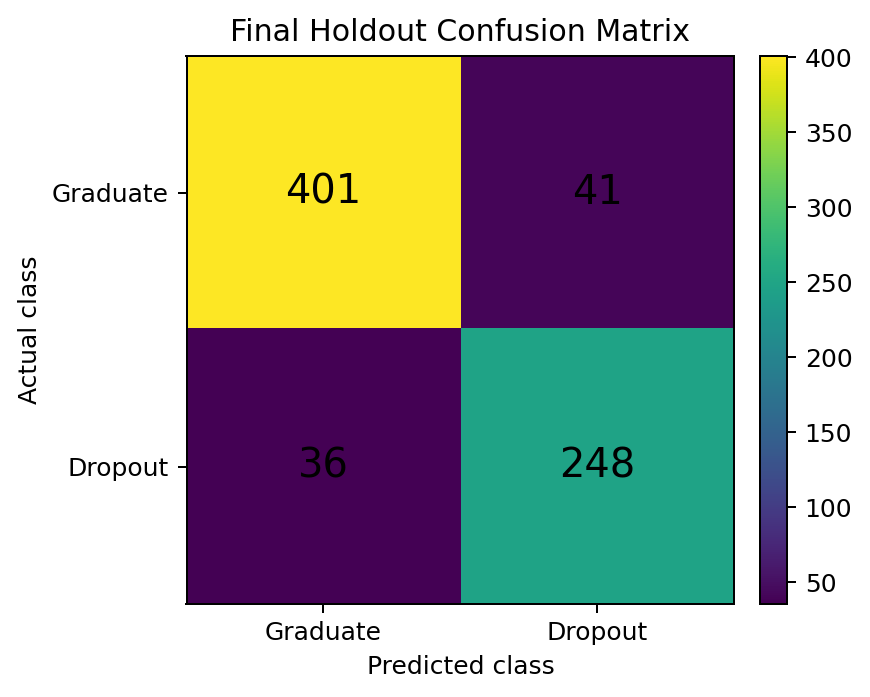

**Important:** 36 actual dropouts were missed, so non-alerted students still need alternative support pathways.\
**Final model:** XGBoost, threshold 0.48

# Threshold Trade-off

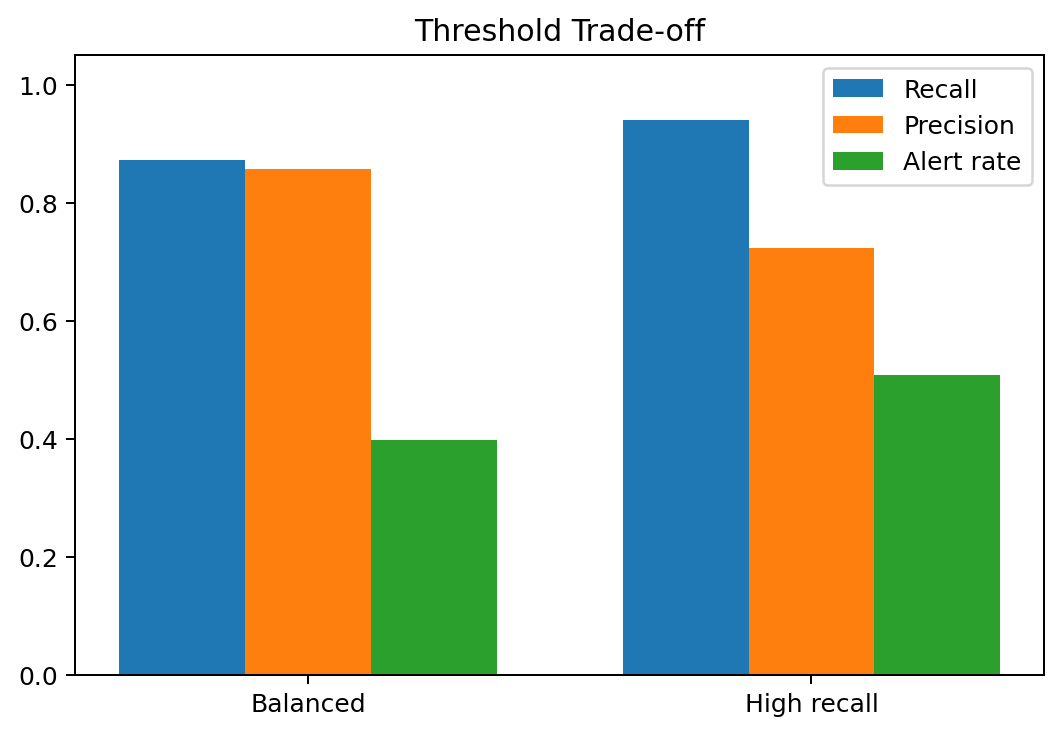

| Policy      |   Threshold |   Recall |   Precision |   Alert rate |   False negatives |
|:------------|------------:|---------:|------------:|-------------:|------------------:|
| Balanced    |      0.4800 |   0.8732 |      0.8581 |       0.3981 |                36 |
| High recall |      0.1800 |   0.9401 |      0.7236 |       0.5083 |                17 |

The 0.48 threshold balances dropout recall and alert workload. Threshold changes should require a new development and validation cycle.

# Global Explainability: SHAP + PDP

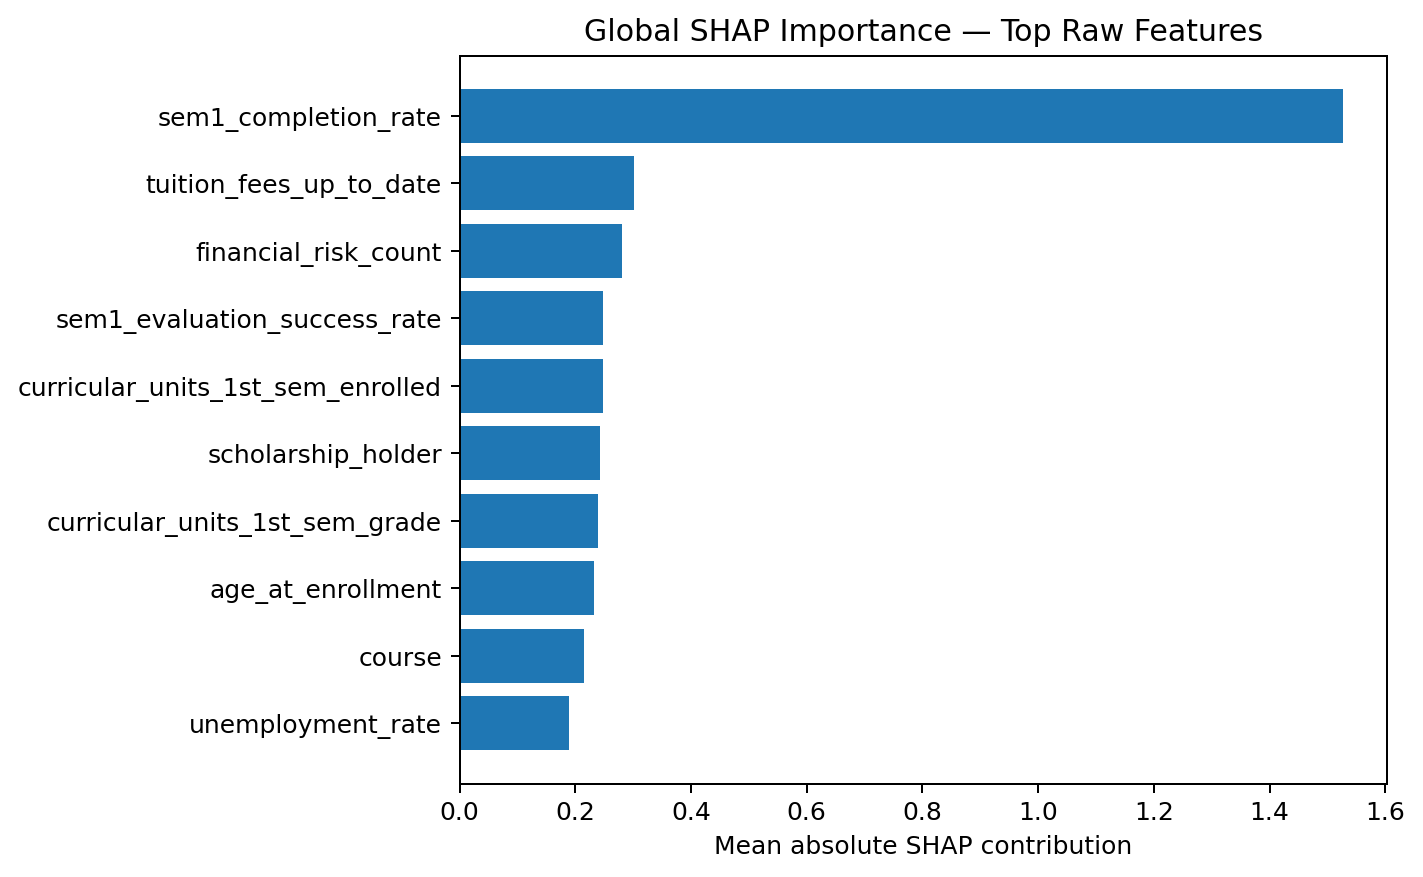

**Interpretation:** `sem1_completion_rate` is the dominant global driver. Academic progress and financial/administrative signals also contribute materially.

# PDP: Semester 1 Completion Rate

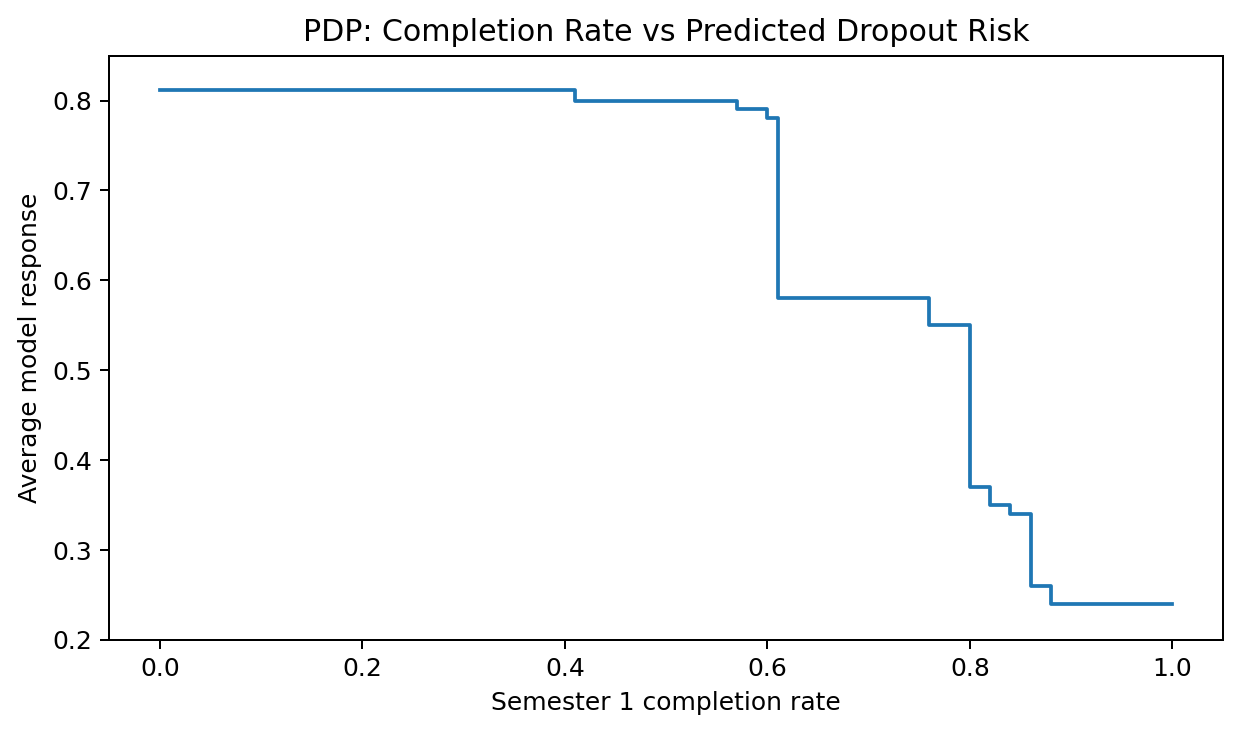

The model learns a strong nonlinear inverse association: higher Semester 1 completion is associated with lower predicted dropout risk.

**Caution:** PDP describes model behavior and predictive association, not causality.

# Local Explainability: ICE + LIME

**ICE finding:** individual responses vary, confirming interactions across academic, financial, demographic, and program variables.

**LIME example:** a correctly identified dropout case had predicted dropout probability **0.9708**. Low transformed Semester 1 completion contributed toward increased predicted risk.

**Caveat:** LIME was generated in the 228-feature transformed space; one-hot encoded category terms should be interpreted cautiously.

# Formal Fairness Metrics

| Dimension      |   Demo parity gap |   DI ratio |   Equal opp gap |   Eq odds gap |
|:---------------|------------------:|-----------:|----------------:|--------------:|
| Financial risk |            51.100 |      0.357 |          20.100 |        20.100 |
| Debtor status  |            42.500 |      0.451 |          16.200 |        16.200 |
| Age            |            47.000 |      0.373 |          15.100 |        15.100 |
| Scholarship    |            33.500 |      0.300 |          11.400 |        11.400 |
| Gender         |            23.200 |      0.568 |           3.600 |         6.000 |
| Displacement   |            15.300 |      0.683 |           4.900 |         4.900 |

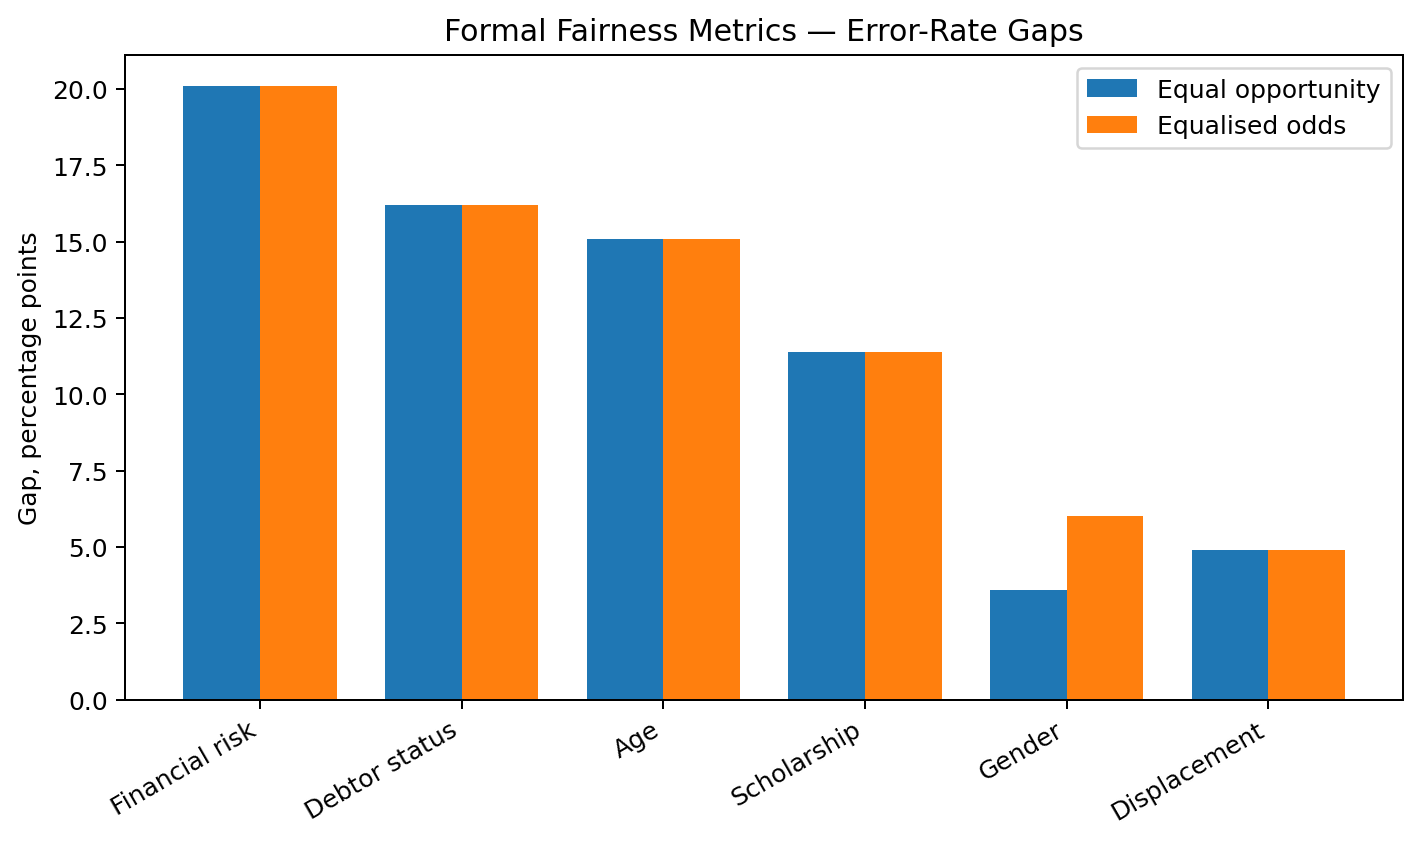

Equal opportunity and equalised odds are more operationally informative than demographic parity alone for this supportive early-warning use case.

# Limitations and Responsible AI Controls

## Key technical limitations

- Moderate class imbalance; evaluate beyond accuracy.
- Temporal leakage risk; enforce End-of-Semester-1 horizon.
- False negatives remain; non-alerts cannot mean no risk.
- Fairness estimates require minimum subgroup support.
- SHAP/LIME/PDP/ICE explain associations, not causal effects.

## Required safeguards

- Human review of alerts and documented overrides.
- No autonomous adverse or eligibility decisions.
- Alternative referral pathway for non-alerted students.
- Recurring subgroup, calibration, and program monitoring.
- Privacy controls and audit logging.

# Technical Conclusion

## Deployment recommendation

> **CONDITIONAL GO — SUPPORTIVE DECISION SUPPORT ONLY**

The final XGBoost model provides strong predictive performance, but subgroup heterogeneity and false negatives require human oversight and continuous monitoring.

## Reproducibility handoff

- Final report: `reports/final_report.md`
- Reproducible source: `src/`
- Fairness documentation: `docs/bias_fairness_analysis.md`
- Model card: `docs/model_card.md`
- Governance controls: `docs/responsible_ai.md`

**FINAL_MODEL** = "XGBoost"\
**FINAL_THRESHOLD** = 0.48\
**HOLDOUT_RECORDS** = 726\
**TRAINING_RECORDS** = 2904